<table>
    <tr>
        <td style="text-align:left">
            <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR9ItLTT_F-3Q30cu7ZCCoKmuFGBt22pe7pNA" alt="Logo Universidad" width="300"/>
        </td>
        <td>
            Departamento de Ciencias de la Computación y de la Decisión<br>
            Facultad de Minas<br>
            Universidad Nacional de Colombia<br>
            Optimizacion e IA 2026-2S<br><br>
            Estudiante: Juan Gabriel Carvajal Negrete<br>
            <br>
            Maestria En Ingenieria Analitica 
        </td>    
    </tr>
</table>

**Parte 2 : GRADIENTE DESCENDENTE**

In [1]:
#--------------------- Importación de librerias -----------------------#
########################################################################

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import rand

**Expresión de la función :** Esta función es la que nos va a interesas optimizar mediante el gradiente descendente.

$f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2 \quad \text{para } x, y \in [-5, 5]$

In [ ]:
#Definimos la funcion objetivo
def objetivo(x,y):
  return (x**2 + y - 11)**2 + (x + y**2 - 7)**2


In [3]:
xi = np.arange(-5,5,0.1) # Generamos valores para la variable x
yi = np.arange(-5,5,0.1) # Generamos valores aleatorios para la variable y
x,y = np.meshgrid(xi,yi) # Luego encontramos todo el  conjunto de combinaciones de las varaibles x , y
feval =  objetivo(x,y)

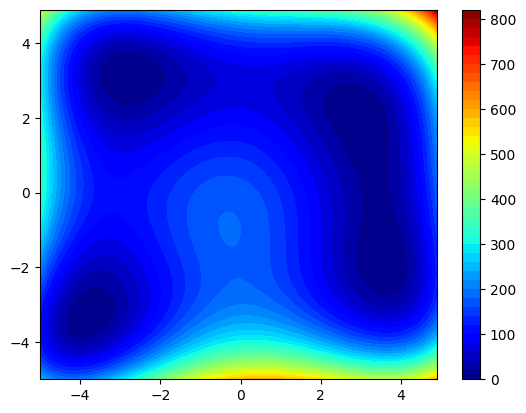

In [4]:
plt.contourf(x, y, feval, levels=50, cmap='jet')
plt.colorbar()
plt.show()

Para el correcto funcionamiento del algoritmo modificaremos las funciones de tal forma que ahora de entrada reciban un vector de dos dimenciones.

In [21]:
# Programamos el algotimo del gradiente descendente

def objetivo(solution):
    x, y = solution[0], solution[1]
    return np.array([(x**2 + y - 11)**2 + (x + y**2 - 7)**2])

def derivada(solution):
    x, y = solution[0], solution[1]
    df_dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    df_dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([df_dx, df_dy])



#Algoritmo de gradiente descendente
def gradient_descent(objetivo,derivada,bounds,n_inter,step_size,my_flag):
    
  # Guardamos las soluciones en una lista
  solutions, scores = list(), list()
  # Generamos el punto inicial de forma aleatoria
  solution = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1] - bounds[:, 0])

	# Algoritmo iterativo
  for i in range(n_inter):
		#1. Calculo del gradiente
    gradient = derivada(solution)
		#2. Actualizacion de la solucion
    solution = solution - step_size*gradient
  	#3. Evaluacion de la solucion
    solution_eval = objetivo(solution)
  	#Almacenamos la solucion
    solutions.append(solution)
    scores.append(solution_eval)
		#Mostramos el progreso
    if my_flag:
      print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
  return [solutions, scores]

In [ ]:
# Deliminatos el rango de los datos
bounds = np.asarray([[-5,5],[-5,5]])
# Definimos el numero de iteraciones
n_inter = 50000
# Seleccionamos la longitud del paso
step_size = 0.00001
# Aplicamos el algoritmo de gradiente descendente
solutions , scores = gradient_descent(objetivo,derivada,bounds,n_inter,step_size,True)
print(solutions[-1][0],solutions[-1][1],scores[-1])

C:\Users\Juan Carvajal\AppData\Local\Temp\ipykernel_8696\4207673395.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>%d f(%s) = %.5f' % (i, solution, solution_eval))


>0 f([-2.95802884 -3.59282559]) = 42.84404
>1 f([-2.95877919 -3.59228473]) = 42.75853
>2 f([-2.95952903 -3.59174469]) = 42.67318
>3 f([-2.96027836 -3.59120549]) = 42.58800
>4 f([-2.96102718 -3.59066711]) = 42.50298
>5 f([-2.9617755  -3.59012955]) = 42.41812
>6 f([-2.96252331 -3.58959283]) = 42.33343
>7 f([-2.96327062 -3.58905692]) = 42.24891
>8 f([-2.96401741 -3.58852183]) = 42.16455
>9 f([-2.96476371 -3.58798757]) = 42.08035
>10 f([-2.96550949 -3.58745412]) = 41.99631
>11 f([-2.96625477 -3.58692149]) = 41.91244
>12 f([-2.96699954 -3.58638968]) = 41.82873
>13 f([-2.96774381 -3.58585869]) = 41.74518
>14 f([-2.96848757 -3.5853285 ]) = 41.66180
>15 f([-2.96923082 -3.58479913]) = 41.57857
>16 f([-2.96997357 -3.58427057]) = 41.49551
>17 f([-2.97071581 -3.58374282]) = 41.41260
>18 f([-2.97145755 -3.58321587]) = 41.32986
>19 f([-2.97219878 -3.58268974]) = 41.24727
>20 f([-2.9729395  -3.58216441]) = 41.16485
>21 f([-2.97367972 -3.58163988]) = 41.08258
>22 f([-2.97441943 -3.58111616]) = 41.0004

Graficamos la función junto con el punto obtimo dado en la función.

In [63]:
print(f"Punto Optimo : x = {solutions[-1][0]} , y = {solutions[-1][1]}\n\
Valor Optimo {scores[-1]}")

Punto Optimo : x = -3.779310253377474 , y = -3.2831859912858308
Valor Optimo [6.7854281e-24]


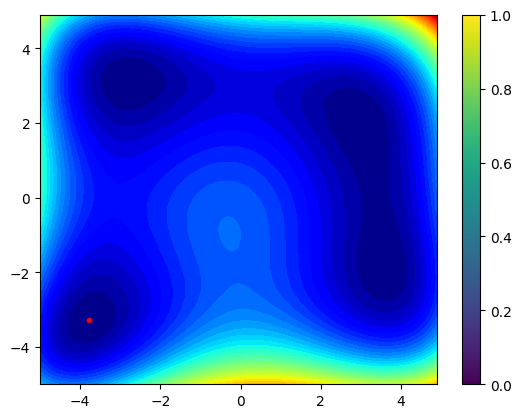

In [64]:
plt.contourf(x, y, feval, levels=50, cmap='jet')
plt.scatter(solutions[-1][0],solutions[-1][1],c='red',marker='.')
plt.colorbar()
plt.show()